# Assessment Problems

## Problem 1: Data from yfinance

Using the yfinance Python package, write a function called get_data() that downloads all hourly data for the previous five days for the five FAANG stocks:


    Facebook (META)
    Apple (AAPL)
    Amazon (AMZN)
    Netflix (NFLX)
    Google (GOOG)

The function should save the data into a folder called data in the root of your repository using a filename with the format YYYYMMDD-HHmmss.csv where YYYYMMDD is the four-digit year (e.g. 2025), followed by the two-digit month (e.g. 09 for September), followed by the two digit day, and HHmmss is hour, minutes, seconds. Create the data folder if you don't already have one.

## Problem 1. Answer

First step is to import the yfinance python package so we can then access the stock data for the five FAANG stocks and the yfinance functions. Pandas should be included in the yfinance import but I will import anyway. Will also import datetime as it will be required later in the question.

In [30]:

# dates and times
import datetime as dt


# data frame , pulled in with yfinance anyway 
import pandas as pd

# import yahoo finance data
import yfinance as yf

# used in problem 2.
# numerical arrays
import numpy as np

#plotting
import matplotlib.pyplot as plt

Next step is to get the stock data required for for each tickers-Facebook(META),Google(GOOG),Apple(AAPL),Amazon(AMZN)
and Netlix(NFLX).

(A ticker is a shortened name for thhe company stock eg. MSFT for microsoft)

Reference: https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html

In [31]:
# Example of how to get the data for one ticker
# dat = yf.Ticker("MSFT")

# for multiple tickers , with spaces to seperate each
Tickers = yf.Tickers('META AAPL GOOG AMZN NFLX')


In [32]:
# to download the data 
# use the download function in yfinance, can also test the period function here to check the data
yf.download(['META', 'AAPL', 'GOOG', 'AMZN', 'NFLX'], period='5d')
# info from below link other examples of periods are eg. 1d,5d,1mo,3mo,6mo,1y,2y,5y,
# https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html

/tmp/ipykernel_11563/2216655638.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  yf.download(['META', 'AAPL', 'GOOG', 'AMZN', 'NFLX'], period='5d')
[*********************100%***********************]  5 of 5 completed


Price            Close                                                 \
Ticker            AAPL        AMZN        GOOG        META       NFLX   
Date                                                                    
2025-12-09  277.179993  227.919998  317.750000  656.960022  96.709999   
2025-12-10  278.779999  231.779999  321.000000  650.130005  92.709999   
2025-12-11  278.029999  230.279999  313.700012  652.710022  94.089996   
2025-12-12  278.279999  226.190002  310.519989  644.229980  95.190002   
2025-12-15  274.109985  222.539993  309.320007  647.510010  93.769997   

Price             High                                                 ...  \
Ticker            AAPL        AMZN        GOOG        META       NFLX  ...   
Date                                                                   ...   
2025-12-09  280.029999  228.570007  318.709015  664.479980  97.239998  ...   
2025-12-10  279.750000  232.419998  321.869995  654.510010  96.970001  ...   
2025-12-11  279.589996  232.110001  321.989990  655.280029  94.820000  ...   
2025-12-12  279.220001  230.080002  316.140015  711.000000  96.919998  ...   
2025-12-15  280.049988  227.929993  312.700012  653.000000  96.370003  ...   

Price             Open                                                 \
Ticker            AAPL        AMZN        GOOG        META       NFLX   
Date                                                                    
2025-12-09  278.160004  226.839996  313.100006  663.770020  97.029999   
2025-12-10  277.750000  228.809998  316.619995  649.950012  96.739998   
2025-12-11  279.100006  230.710007  321.100006  643.289978  93.900002   
2025-12-12  277.899994  229.869995  314.795013  649.799988  95.500000   
2025-12-15  280.019989  227.889999  312.625000  645.424988  96.014999   

Price         Volume                                          
Ticker          AAPL      AMZN      GOOG      META      NFLX  
Date                                                          
2025-12-09  32193300  25841700  14151300  12997100  51745600  
2025-12-10  33038300  38790700  22764500  16910900  74129300  
2025-12-11  33248000  28249600  25912100  13056700  43949000  
2025-12-12  39487400  35576500  21264800  14016900  49226800  
2025-12-15  49752479  45945359  21692668  15196370  39127688  

[5 rows x 25 columns]

In [33]:
# now to add in the interval required which is every hour 
# interval will be '1h'

# get the data 
df = yf.download(['META', 'AAPL', 'GOOG', 'AMZN', 'NFLX'], period='5d', interval='1h')

# check and see if correct
df



/tmp/ipykernel_11563/2938514840.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(['META', 'AAPL', 'GOOG', 'AMZN', 'NFLX'], period='5d', interval='1h')
[*********************100%***********************]  5 of 5 completed


Price                           Close                                      \
Ticker                           AAPL        AMZN        GOOG        META   
Datetime                                                                    
2025-12-09 14:30:00+00:00  277.700012  227.660004  314.142487  656.719971   
2025-12-09 15:30:00+00:00  277.410004  227.839996  314.619995  655.500000   
2025-12-09 16:30:00+00:00  277.875000  227.990005  317.630798  655.330017   
2025-12-09 17:30:00+00:00  278.385010  228.309998  318.670013  657.484985   
2025-12-09 18:30:00+00:00  278.690002  227.979996  318.279999  657.979980   
2025-12-09 19:30:00+00:00  277.864990  227.914993  317.920013  656.349976   
2025-12-09 20:30:00+00:00  277.230011  227.899994  317.790009  656.820007   
2025-12-10 14:30:00+00:00  277.450012  231.735001  318.739990  651.317505   
2025-12-10 15:30:00+00:00  278.257690  231.660004  318.600006  652.849182   
2025-12-10 16:30:00+00:00  278.526489  230.720001  317.075104  650.250000   
2025-12-10 17:30:00+00:00  278.119995  230.335007  316.700012  644.843811   
2025-12-10 18:30:00+00:00  278.220001  230.264999  318.609985  645.489990   
2025-12-10 19:30:00+00:00  278.980011  231.919998  320.510010  647.919983   
2025-12-10 20:30:00+00:00  278.720001  231.690002  320.850006  649.929993   
2025-12-11 14:30:00+00:00  276.119995  230.880005  317.059998  652.609985   
2025-12-11 15:30:00+00:00  275.825012  228.850006  315.549988  646.609985   
2025-12-11 16:30:00+00:00  277.904999  230.082504  316.059998  648.840027   
2025-12-11 17:30:00+00:00  277.522614  229.479996  313.390015  649.390015   
2025-12-11 18:30:00+00:00  277.760010  229.844193  313.605011  651.919983   
2025-12-11 19:30:00+00:00  278.095001  229.692505  313.350006  650.549988   
2025-12-11 20:30:00+00:00  278.059998  230.270004  313.709991  652.780029   
2025-12-12 14:30:00+00:00  277.869995  226.380005  309.589996  644.010010   
2025-12-12 15:30:00+00:00  277.739990  226.020004  308.000000  641.469971   
2025-12-12 16:30:00+00:00  277.855011  226.330002  309.570007  643.219971   
2025-12-12 17:30:00+00:00  279.049988  226.990005  311.649994  647.500122   
2025-12-12 18:30:00+00:00  277.950012  226.850006  310.962799  645.309998   
2025-12-12 19:30:00+00:00  278.054993  226.712006  310.799988  645.349976   
2025-12-12 20:30:00+00:00  278.369995  226.190002  310.510010  644.239990   
2025-12-15 14:30:00+00:00  274.144989  223.029999  307.730011  641.054993   
2025-12-15 15:30:00+00:00  275.510010  224.389999  308.829987  650.545105   
2025-12-15 16:30:00+00:00  274.920013  222.544998  306.142609  650.309998   
2025-12-15 17:30:00+00:00  274.040009  222.375000  307.450012  650.219971   
2025-12-15 18:30:00+00:00  273.369995  223.222595  308.540009  651.219971   
2025-12-15 19:30:00+00:00  273.804993  222.664993  309.364990  650.994995   
2025-12-15 20:30:00+00:00  274.114990  222.550003  309.338989  647.500000   

Price                                       High                          \
Ticker                          NFLX        AAPL        AMZN        GOOG   
Datetime                                                                   
2025-12-09 14:30:00+00:00  96.644997  280.029999  227.750000  314.571503   
2025-12-09 15:30:00+00:00  96.065002  278.000000  228.570007  315.269989   
2025-12-09 16:30:00+00:00  95.925003  278.119995  228.360001  317.679993   
2025-12-09 17:30:00+00:00  95.783798  278.739990  228.410004  318.708893   
2025-12-09 18:30:00+00:00  96.589897  278.890015  228.410004  318.700012   
2025-12-09 19:30:00+00:00  96.849998  278.750000  228.283707  318.475006   
2025-12-09 20:30:00+00:00  96.709999  278.250000  228.080002  318.019989   
2025-12-10 14:30:00+00:00  95.525002  278.792999  232.419998  319.519989   
2025-12-10 15:30:00+00:00  94.949997  278.279999  232.020004  318.859589   
2025-12-10 16:30:00+00:00  94.790001  278.890015  232.110001  318.825012   
2025-12-10 17:30:00+00:00  94.220001  279.279999  231.600006  318.029510   
2025-12-1

now that the required data is downloaded we need to save it to a data folder
but first we must format the df to a csv and the name to a date and time required using datetime functions

imported above

reference : https://docs.python.org/3/library/datetime.html
reference : https://www.w3schools.com/python/python_datetime.asp
refernece : https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html


In [34]:
# csv to data folder
# this is how to save the df to a csv file in data folder 

# df.to_csv('data/data.csv')

# but first we must format the date time name as below

In [35]:
## file name and datetime set up 

# below function found on https://docs.python.org/3/library/datetime.html and explained in Ian McLoughlin video lectures.

# now.straftime will output a string 
# ("%Y%m%d %H%M%S") is the format of the string output in (yearmonthdate hourminutesecond)
# can add spaces but neater and shorter like this
# and csv is the extension

# now.strftime("%Y%m%d %H%M%S") + ".csv"


# command (folder + file + extension)
# df.to_csv("data/" + now.strftime("%Y%m%d %H%M%S") + ".csv")

# if above one is run again it will OVERRIGHT the current file in data folder with new information


# change now.strftime function to dt.datetime.now() 
# will save different file each time , with time stamp for name 
df.to_csv("data/" + dt.datetime.now().strftime("%Y%m%d %H%M%S") + ".csv")

## Problem 2: Plotting Data
Write a function called plot_data() that opens the latest data file in the data folder and, on one plot, plots the Close prices for each of the five stocks. The plot should include axis labels, a legend, and the date as a title. The function should save the plot into a plots folder in the root of your repository using a filename in the format YYYYMMDD-HHmmss.png. Create the plots folder if you don't already have one.

<Axes: xlabel='Datetime'>

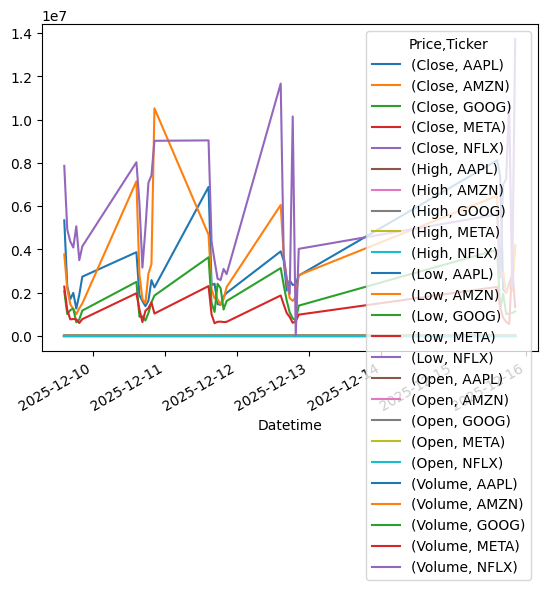

In [36]:
# first check the plot 
df.plot()

In [37]:
# to check the columns, we making sure the close column is there

df.columns

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'AMZN'),
            ( 'Close', 'GOOG'),
            ( 'Close', 'META'),
            ( 'Close', 'NFLX'),
            (  'High', 'AAPL'),
            (  'High', 'AMZN'),
            (  'High', 'GOOG'),
            (  'High', 'META'),
            (  'High', 'NFLX'),
            (   'Low', 'AAPL'),
            (   'Low', 'AMZN'),
            (   'Low', 'GOOG'),
            (   'Low', 'META'),
            (   'Low', 'NFLX'),
            (  'Open', 'AAPL'),
            (  'Open', 'AMZN'),
            (  'Open', 'GOOG'),
            (  'Open', 'META'),
            (  'Open', 'NFLX'),
            ('Volume', 'AAPL'),
            ('Volume', 'AMZN'),
            ('Volume', 'GOOG'),
            ('Volume', 'META'),
            ('Volume', 'NFLX')],
           names=['Price', 'Ticker'])

<Axes: xlabel='Datetime'>

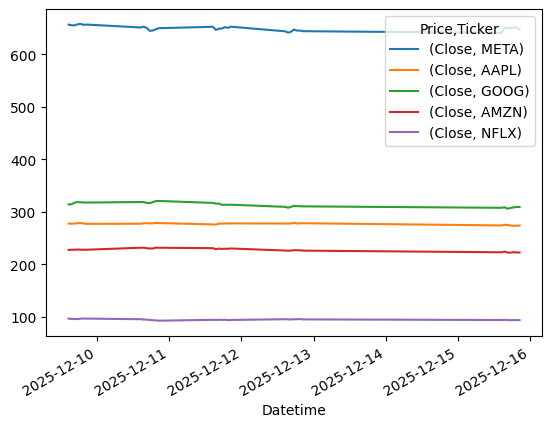

In [38]:
# to get the closing prices for each ticker
df[[('Close', 'META'), ('Close', 'AAPL'), ('Close', 'GOOG'), ('Close', 'AMZN'), ('Close', 'NFLX')]].plot()

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html

## Problem 3: Script
Create a Python script called faang.py in the root of your repository. Copy the above functions into it and make it so that whenever someone at the terminal types ./faang.py, the script runs, downloading the data and creating the plot. Note that this will require a shebang line and the script to be marked executable. Explain the steps you took in your notebook.

## Problem 4: Automation
Create a GitHub Actions workflow to run your script every Saturday morning. The script should be called faang.yml in a .github/workflows/ folder in the root of your repository. In your notebook, explain each of the individual lines in your workflow.